# Exploratory Data Analysis — OnlenPajak Student Pipeline

**Data sources** (relative to project root `data/`):
- `data/students.csv` — 1,200 students across 10 classes
- `data/attendance.csv` — 5,000 attendance records
- `data/assessments.json` — 3,000 assessment records

**Key findings (summary):**
- No nulls across all three sources 
- No orphan FK violations 
- **171 duplicate (student_id, attendance_date) pairs** → handled in Silver
- **15 duplicate (student_id, subject, assessment_date) triples** → handled in Silver
- All `students.updated_at` are uniform (static dump, no incremental CDC yet)

In [2]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

# Resolve data directory relative to this notebook (notebooks/ -> data/)
import os
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath('01_eda.ipynb')), '..', 'data')
DATA_PATH = os.path.normpath(DATA_PATH)
print(f'Data path: {DATA_PATH}')
print('Libraries loaded ✓')

Data path: /Users/mahesaark/Documents/playground/bootcamp/onlenpajak/data
Libraries loaded ✓


## 1. Load Data

In [3]:
students   = pd.read_csv(f'{DATA_PATH}/students.csv')
attendance = pd.read_csv(f'{DATA_PATH}/attendance.csv')
with open(f'{DATA_PATH}/assessments.json') as f:
    assessments = pd.DataFrame(json.load(f))

print(f'Students:    {students.shape}')
print(f'Attendance:  {attendance.shape}')
print(f'Assessments: {assessments.shape}')

Students:    (1200, 6)
Attendance:  (5000, 5)
Assessments: (3000, 7)


## 2. Students — Profile

In [4]:
students.head()

,student_id,student_name,class_id,grade_level,enrollment_status,updated_at
0,S-0001,Student 1,CLASS-02,10,ACTIVE,2025-01-01T00:00:00
1,S-0002,Student 2,CLASS-05,10,ACTIVE,2025-01-01T00:00:00
2,S-0003,Student 3,CLASS-04,10,ACTIVE,2025-01-01T00:00:00
3,S-0004,Student 4,CLASS-02,12,ACTIVE,2025-01-01T00:00:00
4,S-0005,Student 5,CLASS-09,10,ACTIVE,2025-01-01T00:00:00


In [5]:
print('=== STUDENTS PROFILE ===')
print(f'Shape: {students.shape}')
print(f'\nNull counts:')
print(students.isnull().sum())
print(f'\nstudent_id duplicates: {students["student_id"].duplicated().sum()}')
print(f'enrollment_status values: {dict(students["enrollment_status"].value_counts())}')
print(f'grade_level values: {sorted(students["grade_level"].unique())}')
print(f'class_id unique ({students["class_id"].nunique()}): {sorted(students["class_id"].unique())}')
print(f'updated_at unique: {students["updated_at"].unique()[:3]}')
print('\n⚠  All updated_at are identical → static snapshot, not CDC-enabled yet')

=== STUDENTS PROFILE ===
Shape: (1200, 6)

Null counts:
student_id           0
student_name         0
class_id             0
grade_level          0
enrollment_status    0
updated_at           0
dtype: int64

student_id duplicates: 0
enrollment_status values: {'ACTIVE': np.int64(1200)}
grade_level values: [np.int64(10), np.int64(11), np.int64(12)]
class_id unique (10): ['CLASS-01', 'CLASS-02', 'CLASS-03', 'CLASS-04', 'CLASS-05', 'CLASS-06', 'CLASS-07', 'CLASS-08', 'CLASS-09', 'CLASS-10']
updated_at unique: <StringArray>
['2025-01-01T00:00:00']
Length: 1, dtype: str

⚠  All updated_at are identical → static snapshot, not CDC-enabled yet


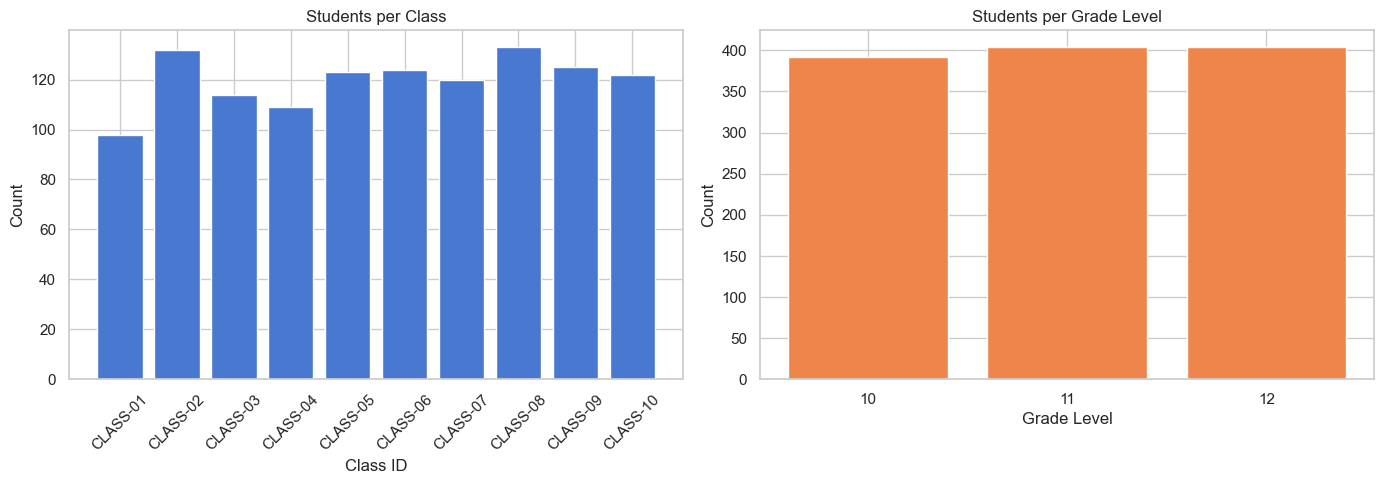

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Students per class
class_counts = students['class_id'].value_counts().sort_index()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('muted')[0])
axes[0].set_title('Students per Class')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Students per grade level
grade_counts = students['grade_level'].value_counts().sort_index()
axes[1].bar(grade_counts.index.astype(str), grade_counts.values, color=sns.color_palette('muted')[1])
axes[1].set_title('Students per Grade Level')
axes[1].set_xlabel('Grade Level')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Attendance — Profile & Quality Checks

In [7]:
attendance.head()

,attendance_id,student_id,attendance_date,status,created_at
0,ATT-00001,S-0871,2025-01-29,ABSENT,2025-01-29T00:00:00
1,ATT-00002,S-0112,2025-01-17,ABSENT,2025-01-17T00:00:00
2,ATT-00003,S-0449,2025-02-01,ABSENT,2025-02-01T00:00:00
3,ATT-00004,S-0094,2025-02-10,ABSENT,2025-02-10T00:00:00
4,ATT-00005,S-0840,2025-01-29,PRESENT,2025-01-29T00:00:00


In [10]:
attendance['attendance_date'] = pd.to_datetime(attendance['attendance_date'])
attendance['created_at']      = pd.to_datetime(attendance['created_at'])

print('=== ATTENDANCE PROFILE ===')
print(f'Shape: {attendance.shape}')
print(f'\nNull counts:')
print(attendance.isnull().sum())
print(f'\nstatus values: {dict(attendance["status"].value_counts())}')
print(f'attendance_id duplicates: {attendance["attendance_id"].duplicated().sum()}')
print(f'Date range: {attendance["attendance_date"].min().date()} → {attendance["attendance_date"].max().date()}')

# Orphan check
orphans = attendance[~attendance['student_id'].isin(students['student_id'])]
print(f'\nOrphan student_ids (not in students): {len(orphans)} OK' if len(orphans)==0 else f'ORPHANS: {orphans["student_id"].unique()}')

# Duplicate (student_id, date) check
dup_mask = attendance.duplicated(subset=['student_id', 'attendance_date'], keep=False)
dups = attendance[dup_mask]
print(f'\n⚠  Duplicate (student_id, attendance_date) pairs: {attendance.duplicated(subset=["student_id","attendance_date"]).sum()}')
print(f'   Total rows affected: {len(dups)}')

=== ATTENDANCE PROFILE ===
Shape: (5000, 5)

Null counts:
attendance_id      0
student_id         0
attendance_date    0
status             0
created_at         0
dtype: int64

status values: {'PRESENT': np.int64(2505), 'ABSENT': np.int64(2495)}
attendance_id duplicates: 0
Date range: 2025-01-01 → 2025-03-02

Orphan student_ids (not in students): 0 OK

⚠  Duplicate (student_id, attendance_date) pairs: 171
   Total rows affected: 333


In [11]:
# Investigate duplicates — are they PRESENT+ABSENT or PRESENT+PRESENT?
dup_analysis = (
    dups.groupby(['student_id', 'attendance_date'])['status']
    .apply(lambda x: '+'.join(sorted(x.values)))
    .value_counts()
)
print('Duplicate status combinations:')
print(dup_analysis)
print('\n→ Dedup strategy: PRESENT > ABSENT, then latest created_at')

Duplicate status combinations:
status
ABSENT+PRESENT             77
ABSENT+ABSENT              41
PRESENT+PRESENT            35
ABSENT+ABSENT+PRESENT       3
ABSENT+ABSENT+ABSENT        3
ABSENT+PRESENT+PRESENT      2
PRESENT+PRESENT+PRESENT     1
Name: count, dtype: int64

→ Dedup strategy: PRESENT > ABSENT, then latest created_at


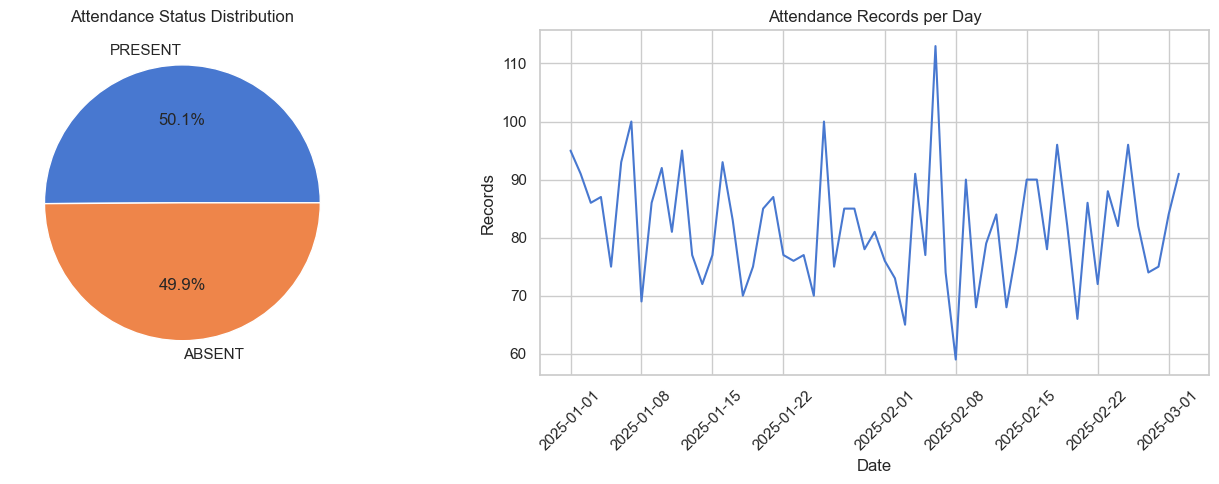

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Status distribution
status_counts = attendance['status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted'))
axes[0].set_title('Attendance Status Distribution')

# Records over time
daily = attendance.groupby('attendance_date').size().reset_index(name='count')
axes[1].plot(daily['attendance_date'], daily['count'], linewidth=1.5)
axes[1].set_title('Attendance Records per Day')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Records')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Assessments — Profile & Quality Checks

In [13]:
assessments.head()

,assessment_id,student_id,subject,score,max_score,assessment_date,created_at
0,ASM-00001,S-0942,English,74,100,2025-01-12,2025-01-12T01:00:00
1,ASM-00002,S-0542,History,52,100,2025-01-23,2025-01-23T01:00:00
2,ASM-00003,S-0572,English,54,100,2025-01-16,2025-01-16T01:00:00
3,ASM-00004,S-0610,English,85,100,2025-03-02,2025-03-02T01:00:00
4,ASM-00005,S-1002,English,70,100,2025-01-14,2025-01-14T01:00:00


In [14]:
assessments['assessment_date'] = pd.to_datetime(assessments['assessment_date'])
assessments['created_at']      = pd.to_datetime(assessments['created_at'])
assessments['score']           = assessments['score'].astype(float)
assessments['max_score']       = assessments['max_score'].astype(float)

print('=== ASSESSMENTS PROFILE ===')
print(f'Shape: {assessments.shape}')
print(f'\nNull counts:')
print(assessments.isnull().sum())
print(f'\nsubject values: {dict(assessments["subject"].value_counts())}')
print(f'max_score unique: {assessments["max_score"].unique()}')
print(f'\nScore statistics:')
print(assessments['score'].describe().round(2))
print(f'\nassessment_id duplicates: {assessments["assessment_id"].duplicated().sum()}')
print(f'Date range: {assessments["assessment_date"].min().date()} → {assessments["assessment_date"].max().date()}')

# Orphan check
orphans = assessments[~assessments['student_id'].isin(students['student_id'])]
print(f'\nOrphan student_ids: {len(orphans)} ✅' if len(orphans)==0 else f'ORPHANS: {orphans["student_id"].unique()}')

# Duplicate (student, subject, date) check
print(f'\n⚠  Duplicate (student_id, subject, assessment_date): {assessments.duplicated(subset=["student_id","subject","assessment_date"]).sum()}')

=== ASSESSMENTS PROFILE ===
Shape: (3000, 7)

Null counts:
assessment_id      0
student_id         0
subject            0
score              0
max_score          0
assessment_date    0
created_at         0
dtype: int64

subject values: {'Math': np.int64(783), 'Science': np.int64(757), 'History': np.int64(747), 'English': np.int64(713)}
max_score unique: [100.]

Score statistics:
count    3000.00
mean       69.85
std        17.55
min        40.00
25%        55.00
50%        70.00
75%        85.00
max       100.00
Name: score, dtype: float64

assessment_id duplicates: 0
Date range: 2025-01-01 → 2025-03-02

Orphan student_ids: 0 ✅

⚠  Duplicate (student_id, subject, assessment_date): 15


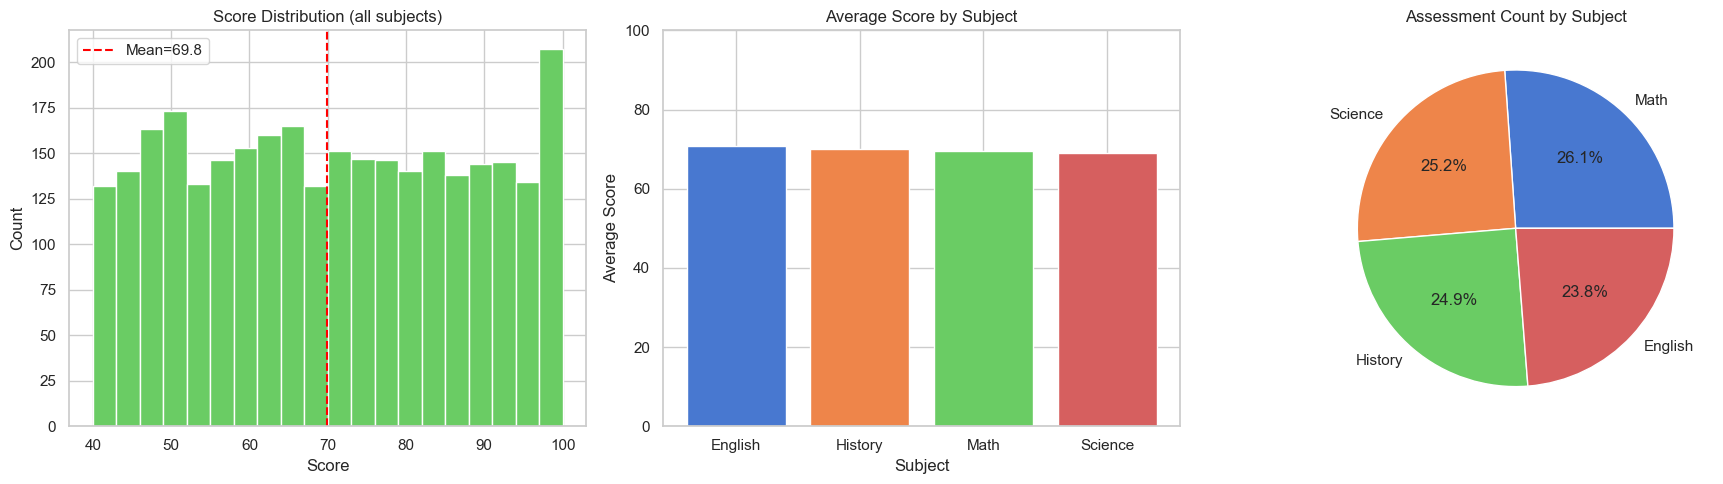

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score distribution
axes[0].hist(assessments['score'], bins=20, color=sns.color_palette('muted')[2], edgecolor='white')
axes[0].set_title('Score Distribution (all subjects)')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')
axes[0].axvline(assessments['score'].mean(), color='red', linestyle='--', label=f'Mean={assessments["score"].mean():.1f}')
axes[0].legend()

# Avg score by subject
subj_avg = assessments.groupby('subject')['score'].mean().sort_values(ascending=False)
axes[1].bar(subj_avg.index, subj_avg.values, color=sns.color_palette('muted'))
axes[1].set_title('Average Score by Subject')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Average Score')
axes[1].set_ylim(0, 100)

# Subject distribution
subj_counts = assessments['subject'].value_counts()
axes[2].pie(subj_counts.values, labels=subj_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted'))
axes[2].set_title('Assessment Count by Subject')

plt.tight_layout()
plt.show()

## 5. Cross-Dataset Analysis

In [16]:
# Attendance rate per class (after dedup)
att_deduped = (
    attendance
    .sort_values(['student_id', 'attendance_date', 'status'], key=lambda x: x.map({'PRESENT': 0, 'ABSENT': 1}) if x.name == 'status' else x)
    .drop_duplicates(subset=['student_id', 'attendance_date'], keep='first')
)
print(f'After dedup: {len(att_deduped)} records (removed {len(attendance) - len(att_deduped)} dupes)')

# Merge with students to get class_id
att_with_class = att_deduped.merge(students[['student_id', 'class_id']], on='student_id')

# Attendance rate per class (present / total students in class)
class_totals = students.groupby('class_id')['student_id'].count().reset_index(name='total_students')
class_present = att_with_class[att_with_class['status']=='PRESENT'].groupby('class_id').size().reset_index(name='total_present')
class_att = class_totals.merge(class_present, on='class_id')
class_att['days_recorded'] = att_with_class.groupby('class_id')['attendance_date'].nunique().values
class_att['avg_daily_attendance_rate'] = (
    att_with_class[att_with_class['status']=='PRESENT'].groupby('class_id').size() /
    (class_totals.set_index('class_id')['total_students'] * att_with_class.groupby('class_id')['attendance_date'].nunique())
).round(4).reset_index(name='rate')['rate'].values

print('\nAttendance rate by class:')
class_att.sort_values('class_id')

After dedup: 4829 records (removed 171 dupes)

Attendance rate by class:


,class_id,total_students,total_present,days_recorded,avg_daily_attendance_rate
0,CLASS-01,98,190,61,0.0318
1,CLASS-02,132,281,61,0.0349
2,CLASS-03,114,204,61,0.0293
3,CLASS-04,109,194,61,0.0292
4,CLASS-05,123,266,61,0.0355
5,CLASS-06,124,267,61,0.0353
6,CLASS-07,120,248,61,0.0339
7,CLASS-08,133,282,61,0.0348
8,CLASS-09,125,253,61,0.0332
9,CLASS-10,122,281,61,0.0378


In [17]:
# Average score per class per subject (after dedup)
asm_deduped = (
    assessments
    .sort_values('created_at', ascending=False)
    .drop_duplicates(subset=['student_id', 'subject', 'assessment_date'])
)
print(f'Assessments after dedup: {len(asm_deduped)} (removed {len(assessments) - len(asm_deduped)} dupes)')

asm_with_class = asm_deduped.merge(students[['student_id', 'class_id']], on='student_id')
score_heatmap = asm_with_class.pivot_table(values='score', index='class_id', columns='subject', aggfunc='mean').round(2)
print('\nAverage score by class and subject:')
score_heatmap

Assessments after dedup: 2985 (removed 15 dupes)

Average score by class and subject:


subject,English,History,Math,Science
class_id,,,,
CLASS-01,69.10,68.86,69.17,69.54
CLASS-02,70.92,68.78,73.45,72.45
CLASS-03,70.63,72.17,67.31,68.37
CLASS-04,69.24,71.61,71.27,66.57
CLASS-05,68.68,70.17,74.00,68.30
CLASS-06,72.80,71.68,65.32,67.93
CLASS-07,73.03,72.42,67.23,67.68
CLASS-08,71.54,71.25,70.40,71.86
CLASS-09,67.46,67.84,68.56,69.13


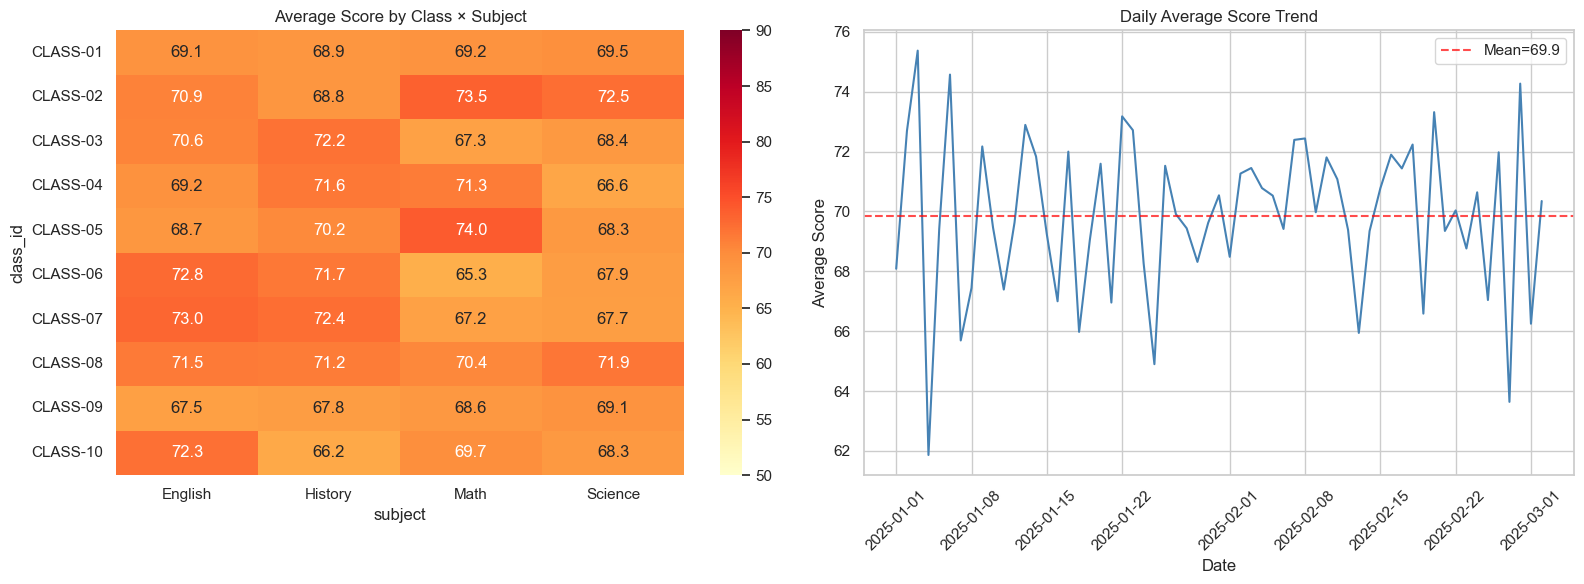

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Score heatmap
sns.heatmap(score_heatmap, annot=True, fmt='.1f', cmap='YlOrRd',
            vmin=50, vmax=90, ax=axes[0])
axes[0].set_title('Average Score by Class × Subject')

# Daily average score trend
daily_score = asm_deduped.groupby('assessment_date')['score'].mean().reset_index()
axes[1].plot(daily_score['assessment_date'], daily_score['score'], linewidth=1.5, color='steelblue')
axes[1].axhline(daily_score['score'].mean(), linestyle='--', color='red', alpha=0.7,
                label=f'Mean={daily_score["score"].mean():.1f}')
axes[1].set_title('Daily Average Score Trend')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Average Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Data Quality Summary

| Issue | Source | Count | Handling |
|-------|--------|-------|----------|
| Duplicate (student_id, attendance_date) | attendance.csv | 171 | Silver: keep PRESENT > ABSENT, latest created_at |
| Duplicate (student_id, subject, assessment_date) | assessments.json | 15 | Silver: keep latest created_at |
| Uniform updated_at | students.csv | all rows | Design for SCD2 when CDC is available |
| All students ACTIVE | students.csv | all rows | Filter enforcement in mart (enrollment_status='ACTIVE') |
| Orphan FK violations | attendance & assessments | 0 | No action needed |
| Null values | all sources | 0 | No action needed |

In [20]:
print('=== PIPELINE READINESS CHECKLIST ===')
checks = [
    ('students.csv has no nulls',        students.isnull().sum().sum() == 0),
    ('attendance.csv has no nulls',      attendance.isnull().sum().sum() == 0),
    ('assessments.json has no nulls',    assessments.isnull().sum().sum() == 0),
    ('student_id is unique in students', students['student_id'].is_unique),
    ('No orphan student_ids in attendance', attendance['student_id'].isin(students['student_id']).all()),
    ('No orphan student_ids in assessments', assessments['student_id'].isin(students['student_id']).all()),
    ('Attendance status only PRESENT/ABSENT', attendance['status'].isin(['PRESENT','ABSENT']).all()),
    ('Score <= max_score in all rows',   (assessments['score'] <= assessments['max_score']).all()),
]
for name, result in checks:
    note = 'YES' if result else 'NO'
    print(f'  {note}  {name}')

print('\n⚠  Known issues (handled in Silver layer):')
print(f'  • 171 duplicate (student_id, attendance_date) pairs in attendance')
print(f'  • 15 duplicate (student_id, subject, assessment_date) triples in assessments')

=== PIPELINE READINESS CHECKLIST ===
  YES  students.csv has no nulls
  YES  attendance.csv has no nulls
  YES  assessments.json has no nulls
  YES  student_id is unique in students
  YES  No orphan student_ids in attendance
  YES  No orphan student_ids in assessments
  YES  Attendance status only PRESENT/ABSENT
  YES  Score <= max_score in all rows

⚠  Known issues (handled in Silver layer):
  • 171 duplicate (student_id, attendance_date) pairs in attendance
  • 15 duplicate (student_id, subject, assessment_date) triples in assessments
